In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
filename1 = os.path.join(os.getcwd(),'software_skills.csv')
dfSoftwareSkills = pd.read_csv(filename1, header=0)

In [4]:
dfSoftwareSkills.head()

,O*NET-SOC Code,Title,Workplace Example,Element ID,Element Name,Hot Technology,In Demand
0,11-1011.00,Chief Executives,Adobe Acrobat,2.E.5.b,Document management software,Y,N
1,11-1011.00,Chief Executives,AdSense Tracker,2.E.6.f,Data base user interface and query software,N,N
2,11-1011.00,Chief Executives,Atlassian JIRA,2.E.5.a,Content workflow software,Y,N
3,11-1011.00,Chief Executives,Blackbaud The Raiser's Edge,2.E.6.c,Customer relationship management CRM software,N,N
4,11-1011.00,Chief Executives,ComputerEase construction accounting software,2.E.2.a,Accounting software,N,N


In [5]:
filename2 = os.path.join(os.getcwd(),'transferable_skills.csv')
dfTransferableSkills = pd.read_csv(filename2, header=0)

In [6]:
dfTransferableSkills.head()

,O*NET-SOC Code,Title,Element ID,Element Name,Scale ID,Scale Name,Data Value,N,Standard Error,Lower CI Bound,Upper CI Bound,Recommend Suppress,Not Relevant,Date,Domain Source
0,11-1011.00,Chief Executives,2.B.1.a,Social Perceptiveness,IM,Importance,4.12,8,0.1250,3.8800,4.3700,N,NaN,08/2023,Analyst
1,11-1011.00,Chief Executives,2.B.1.a,Social Perceptiveness,LV,Level,4.25,8,0.1637,3.9292,4.5708,N,N,08/2023,Analyst
2,11-1011.00,Chief Executives,2.B.1.b,Coordination,IM,Importance,4.25,8,0.1637,3.9292,4.5708,N,NaN,08/2023,Analyst
3,11-1011.00,Chief Executives,2.B.1.b,Coordination,LV,Level,4.88,8,0.2266,4.4309,5.3191,N,N,08/2023,Analyst
4,11-1011.00,Chief Executives,2.B.1.c,Persuasion,IM,Importance,4.00,8,0.1890,3.6296,4.3704,N,NaN,08/2023,Analyst


# Check for missing values

In [7]:
nan_count= np.sum(dfSoftwareSkills.isnull(), axis=0)
nan_count

O*NET-SOC Code       0
Title                0
Workplace Example    0
Element ID           0
Element Name         0
Hot Technology       0
In Demand            0
dtype: int64

In [8]:
nan_count= np.sum(dfTransferableSkills.isnull(), axis=0)
nan_count

O*NET-SOC Code            0
Title                     0
Element ID                0
Element Name              0
Scale ID                  0
Scale Name                0
Data Value                0
N                         0
Standard Error            0
Lower CI Bound            0
Upper CI Bound            0
Recommend Suppress        0
Not Relevant          22750
Date                      0
Domain Source             0
dtype: int64

# Dealing only with the Transferable skills data

## Drop rows and that have a val of Y in the Recomend Suppress col

In [9]:
dfTransferableSkills['Recommend Suppress'].unique()

array(['N', 'Y'], dtype=object)

In [10]:
count = (dfTransferableSkills['Recommend Suppress'] == 'Y').sum()
print(count)

136


In [11]:
dfTransferableSkills = dfTransferableSkills.drop(dfTransferableSkills[dfTransferableSkills['Recommend Suppress'] == 'Y'].index)

In [12]:
count = (dfTransferableSkills['Recommend Suppress']== 'Y').sum()
print(count)

0


In [13]:
dfTransferableSkills['Recommend Suppress'].unique()

array(['N'], dtype=object)

 ## Drop rows and that have a val of Y in the Not Relevant col

In [14]:
dfTransferableSkills['Not Relevant'].unique()

array([nan, 'N', 'Y'], dtype=object)

In [15]:
count = (dfTransferableSkills['Not Relevant']== 'Y').sum()
print(count)

3207


In [16]:
dfTransferableSkills = dfTransferableSkills.drop(dfTransferableSkills[dfTransferableSkills['Not Relevant'] == 'Y'].index)

In [17]:
count = (dfTransferableSkills['Not Relevant']== 'Y').sum()
print(count)

0


## Drop rows with a scale name of level

In [18]:
dfTransferableSkills = dfTransferableSkills.drop(dfTransferableSkills[dfTransferableSkills['Scale Name'] == 'Level'].index)

## Droping Columns

In [19]:
dfTransferableSkills.drop(columns=["Not Relevant", "Recommend Suppress", "Standard Error", "Lower CI Bound", "Upper CI Bound", "Date", "Domain Source", "N", "Element ID", "Scale ID"], inplace=True)

In [20]:
dfTransferableSkills.head()

,O*NET-SOC Code,Title,Element Name,Scale Name,Data Value
0,11-1011.00,Chief Executives,Social Perceptiveness,Importance,4.12
2,11-1011.00,Chief Executives,Coordination,Importance,4.25
4,11-1011.00,Chief Executives,Persuasion,Importance,4.00
6,11-1011.00,Chief Executives,Negotiation,Importance,4.12
8,11-1011.00,Chief Executives,Instructing,Importance,3.38


## rename Data value to importance

In [21]:
dfTransferableSkills = dfTransferableSkills.rename(columns={"Data Value": "Importance"})
dfTransferableSkills.head()

,O*NET-SOC Code,Title,Element Name,Scale Name,Importance
0,11-1011.00,Chief Executives,Social Perceptiveness,Importance,4.12
2,11-1011.00,Chief Executives,Coordination,Importance,4.25
4,11-1011.00,Chief Executives,Persuasion,Importance,4.00
6,11-1011.00,Chief Executives,Negotiation,Importance,4.12
8,11-1011.00,Chief Executives,Instructing,Importance,3.38


## drop Scal name col

In [22]:
dfTransferableSkills = dfTransferableSkills.drop(columns=["Scale Name"])


In [23]:
dfTransferableSkills.head()

,O*NET-SOC Code,Title,Element Name,Importance
0,11-1011.00,Chief Executives,Social Perceptiveness,4.12
2,11-1011.00,Chief Executives,Coordination,4.25
4,11-1011.00,Chief Executives,Persuasion,4.00
6,11-1011.00,Chief Executives,Negotiation,4.12
8,11-1011.00,Chief Executives,Instructing,3.38


# drop stuff in other dataset

In [24]:
dfSoftwareSkills = dfSoftwareSkills.drop(columns=["Element ID"])

In [25]:
dfSoftwareSkills.head()

,O*NET-SOC Code,Title,Workplace Example,Element Name,Hot Technology,In Demand
0,11-1011.00,Chief Executives,Adobe Acrobat,Document management software,Y,N
1,11-1011.00,Chief Executives,AdSense Tracker,Data base user interface and query software,N,N
2,11-1011.00,Chief Executives,Atlassian JIRA,Content workflow software,Y,N
3,11-1011.00,Chief Executives,Blackbaud The Raiser's Edge,Customer relationship management CRM software,N,N
4,11-1011.00,Chief Executives,ComputerEase construction accounting software,Accounting software,N,N


In [26]:
dfTransferableSkills.head()

,O*NET-SOC Code,Title,Element Name,Importance
0,11-1011.00,Chief Executives,Social Perceptiveness,4.12
2,11-1011.00,Chief Executives,Coordination,4.25
4,11-1011.00,Chief Executives,Persuasion,4.00
6,11-1011.00,Chief Executives,Negotiation,4.12
8,11-1011.00,Chief Executives,Instructing,3.38


# combine stuff

In [27]:
print(dfTransferableSkills.shape)
print(dfSoftwareSkills.shape)

(22750, 4)
(31821, 6)


In [28]:
dfMerged = dfSoftwareSkills.merge(
    dfTransferableSkills,
    on=["O*NET-SOC Code", "Title"],
    suffixes=("_software", "_transferable")
)

# Checking if it Merge correctly

In [29]:
print(dfMerged.shape)     # or dfMerged2.shape
dfMerged.head(100000)         # eyeball a sample

(779850, 8)


,O*NET-SOC Code,Title,Workplace Example,Element Name_software,Hot Technology,In Demand,Element Name_transferable,Importance
0,11-1011.00,Chief Executives,Adobe Acrobat,Document management software,Y,N,Social Perceptiveness,4.12
1,11-1011.00,Chief Executives,Adobe Acrobat,Document management software,Y,N,Coordination,4.25
2,11-1011.00,Chief Executives,Adobe Acrobat,Document management software,Y,N,Persuasion,4.00
3,11-1011.00,Chief Executives,Adobe Acrobat,Document management software,Y,N,Negotiation,4.12
4,11-1011.00,Chief Executives,Adobe Acrobat,Document management software,Y,N,Instructing,3.38
...,...,...,...,...,...,...,...,...
99995,13-1111.00,Management Analysts,LexisNexis,Information retrieval or search software,N,N,Systems Evaluation,3.88
99996,13-1111.00,Management Analysts,LexisNexis,Information retrieval or search software,N,N,Time Management,3.25
99997,13-1111.00,Management Analysts,LexisNexis,Information retrieval or search software,N,N,Management of Financial Resources,2.25
99998,13-1111.00,Management Analysts,LexisNexis,Information retrieval or search software,N,N,Management of Material Resources,2.25


In [30]:
dfSoftwareSkills.head(505)

,O*NET-SOC Code,Title,Workplace Example,Element Name,Hot Technology,In Demand
0,11-1011.00,Chief Executives,Adobe Acrobat,Document management software,Y,N
1,11-1011.00,Chief Executives,AdSense Tracker,Data base user interface and query software,N,N
2,11-1011.00,Chief Executives,Atlassian JIRA,Content workflow software,Y,N
3,11-1011.00,Chief Executives,Blackbaud The Raiser's Edge,Customer relationship management CRM software,N,N
4,11-1011.00,Chief Executives,ComputerEase construction accounting software,Accounting software,N,N
...,...,...,...,...,...,...
500,11-2022.00,Sales Managers,IBM Notes,Electronic mail software,N,N
501,11-2022.00,Sales Managers,IBM Power Systems software,Enterprise system management software,N,N
502,11-2022.00,Sales Managers,IBM SPSS Statistics,Analytical or scientific software,Y,N
503,11-2022.00,Sales Managers,Inventory software,Inventory management software,N,N


In [31]:
check = dfMerged[
    (dfMerged["Element Name_software"] == "Document management software") &
    (dfMerged["Element Name_transferable"] == "Social Perceptiveness")
]
print(check)

       O*NET-SOC Code                            Title  \
0          11-1011.00                 Chief Executives   
825        11-1011.00                 Chief Executives   
1200       11-1011.03    Chief Sustainability Officers   
1500       11-1011.03    Chief Sustainability Officers   
1775       11-1021.00  General and Operations Managers   
...               ...                              ...   
768100     53-2021.00          Air Traffic Controllers   
768950     53-2022.00  Airfield Operations Specialists   
773300     53-5031.00                   Ship Engineers   
775250     53-6051.00        Transportation Inspectors   
775825     53-6051.01              Aviation Inspectors   

                            Workplace Example         Element Name_software  \
0                               Adobe Acrobat  Document management software   
825                      Microsoft SharePoint  Document management software   
1200                            Adobe Acrobat  Document management

In [32]:
exists = (
    (dfMerged["Element Name_software"] == "Document management software") &
    (dfMerged["Element Name_transferable"] == "Social Perceptiveness")
).any()
print(exists)

True


In [33]:
check = dfMerged[
    (dfMerged["Title"] == "Chief Executives") &
    (dfMerged["Element Name_software"] == "Document management software") &
    (dfMerged["Element Name_transferable"] == "Social Perceptiveness")
]
print(check)

    O*NET-SOC Code             Title     Workplace Example  \
0       11-1011.00  Chief Executives         Adobe Acrobat   
825     11-1011.00  Chief Executives  Microsoft SharePoint   

            Element Name_software Hot Technology In Demand  \
0    Document management software              Y         N   
825  Document management software              Y         N   

    Element Name_transferable  Importance  
0       Social Perceptiveness        4.12  
825     Social Perceptiveness        4.12  


In [34]:
# can't use cause of format in o*net code

#corrs_matrix = round(dfMerged.corr(), 5)
#corrs_matrix 

In [35]:
dfMerged["Hot Technology_num"] = (dfMerged["Hot Technology"] == "Y").astype(int)
dfMerged["In Demand_num"] = (dfMerged["In Demand"] == "Y").astype(int)

In [36]:
corrs_matrix = round(dfMerged.corr(numeric_only=True), 5)
corrs_matrix

,Importance,Hot Technology_num,In Demand_num
Importance,1.00000,0.00266,-0.00127
Hot Technology_num,0.00266,1.00000,0.30364
In Demand_num,-0.00127,0.30364,1.00000


In [37]:
corrs = corrs_matrix['Importance']
corrs

Importance            1.00000
Hot Technology_num    0.00266
In Demand_num        -0.00127
Name: Importance, dtype: float64

In [38]:
corrs_sorted = corrs.sort_values(ascending=False)
corrs_sorted

Importance            1.00000
Hot Technology_num    0.00266
In Demand_num        -0.00127
Name: Importance, dtype: float64

In [39]:
df_corrs = pd.DataFrame({'Importance': dfMerged['Importance'], 'In Demand': dfMerged['In Demand_num'], 'Hot Technology_num': dfMerged['Hot Technology_num']})

# normaize (will offical do after binary classification and figure out model)

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler



#1. Min-Max Scaling (scales to 0-1 range) -> use if neural network
#numeric_cols = ['Importance']  # replace with your real column names
#scaler = MinMaxScaler()
#dfMerged[numeric_cols] = scaler.fit_transform(dfMerged[numeric_cols])

# 2. Standardization (Z-Score) - use linear regression
#scaler = StandardScaler()
#dfMerged[numeric_cols] = scaler.fit_transform(dfMerged[numeric_cols])

# balance

In [ ]:
# 1. Define 'y' as the column you want to predict (e.g., 'is_fraud' or 'status')
y = dfMerged['In Demand_num']  # Replace with your actual target column name

# 2. Define 'X' as everything EXCEPT that target column
X = dfMerged.drop(columns=['In Demand_num'])

# 3. Now you can safely run your RandomOverSampler code!
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_balanced, y_balanced = ros.fit_resample(X, y)

In [289]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_balanced, y_balanced = ros.fit_resample(X, y)



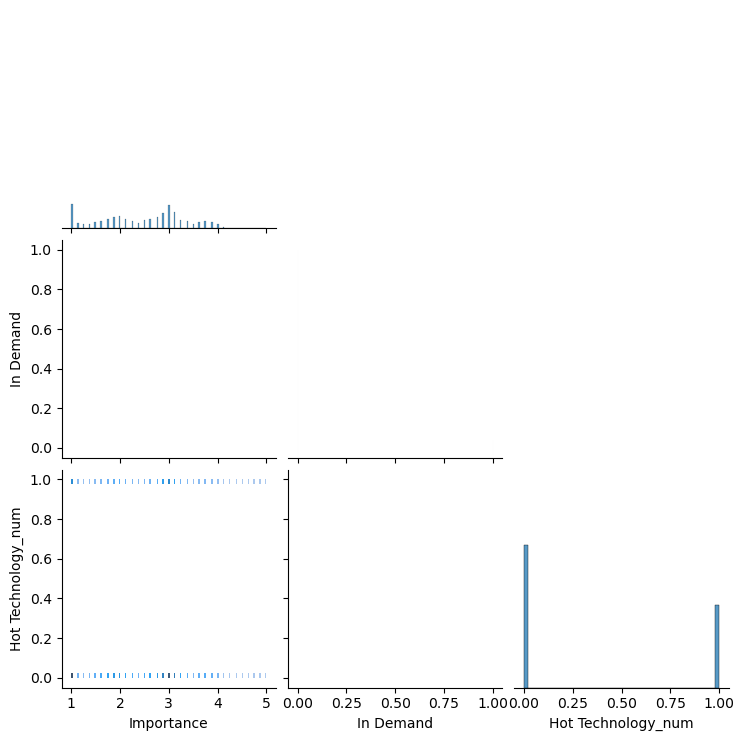

In [290]:
sns.pairplot(data = df_corrs, kind = 'hist', corner = True)

In [ ]:
sns.pairplot(data = df_corrs, kind = 'kde', corner = True)